# EDA: Final ILCS household dataset

Exploratory data analysis of **`ml_households_final_dropped.csv`**: the poverty/socioeconomic dataset after raw → imputed (KNN k=9) → correlation-based column removal. One row per household; columns are curated for poverty and welfare analysis.

## 1. Load and overview

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "ilcs"
FINAL_CSV = DATA_DIR / "final_dropped" / "ml_households_final_dropped.csv"

df = pd.read_csv(FINAL_CSV, low_memory=False)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn dtypes:\n{df.dtypes.value_counts()}")
print(f"\nMissing per column (count):\n{df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().gt(0).any() else 'None'}")
print(f"\nAll columns ({len(df.columns)}):", list(df.columns))

Shape: 5,184 rows × 72 columns

Column dtypes:
float64    66
int64       4
object      2
Name: count, dtype: int64

Missing per column (count):
None

All columns (72): ['recno', 'date', 'household_size', 'weight', 'year', 'household_has_special_education_children', 'dwelling_ownership', 'number_of_rooms', 'has_centralized_water', 'has_hot_water', 'has_centralized_sanitation', 'has_gas', 'has_bathtub_shower', 'has_kitchen', 'has_telephone', 'has_radio', 'has_electricity', 'has_mobile', 'has_computer', 'potable_water_hours_day', 'potable_water_24h', 'heating_spend_last_winter_amd', 'garbage_disposal', 'complaint_floor_space', 'complaint_noise', 'complaint_light', 'complaint_heating', 'complaint_humidity', 'complaint_leaking_roof', 'complaint_walls_floor', 'complaint_traffic', 'complaint_pollution', 'complaint_elevator', 'complaint_water_supply', 'complaint_garbage', 'complaint_green_areas', 'complaint_other', 'dwelling_condition_estimate', 'dwelling_renovated', 'building_new_house', 'has

## 2. Numeric summary

In [2]:
numeric = df.select_dtypes(include=[np.number])
print("Numeric columns:", numeric.shape[1])
numeric.describe().T[["count", "mean", "std", "min", "50%", "max"]].round(2)

Numeric columns: 70


,count,mean,std,min,50%,max
recno,5184.0,2592.50,1496.64,1.00,2592.50,5184.00
date,5184.0,6.50,3.45,1.00,6.50,12.00
household_size,5184.0,3.70,1.88,1.00,4.00,19.00
weight,5184.0,154.96,73.35,21.48,151.50,326.88
year,5184.0,2015.00,0.00,2015.00,2015.00,2015.00
...,...,...,...,...,...,...
services_goods_total,5184.0,224352.99,217158.51,5817.00,169398.50,2759746.00
goods_services_total,5184.0,134182.46,726749.41,711.00,749.00,20655752.00
tsne_1,5184.0,0.11,35.82,-88.75,1.73,79.51
tsne_2,5184.0,-0.15,28.80,-75.21,0.41,68.84


## 3. Key categorical / grouping variables

In [3]:
for col in ["region_label", "area_type_label", "cluster"]:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False).to_string())


--- region_label ---
region_label
Yerevan        1404
Lori            540
Ararat          432
Armavir         432
Shirak          432
Aragatsotn      324
Gegharkunik     324
Kotayk          324
Sjunik          324
Vayots Dzor     324
Tavush          324

--- area_type_label ---
area_type_label
other urban    1944
Yerevan        1836
area_0         1404

--- cluster ---
cluster
4    1637
1    1279
2    1194
5     826
3     149
0      99


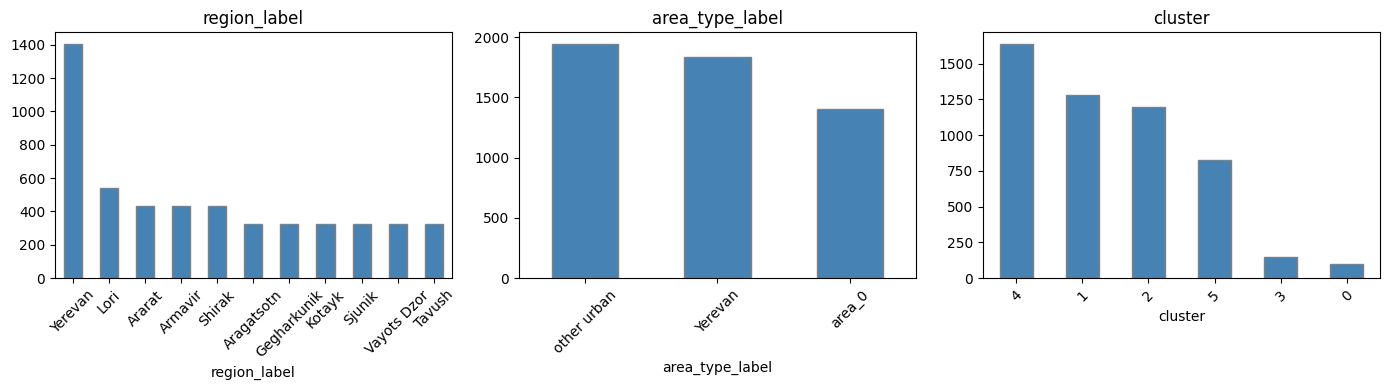

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["region_label", "area_type_label", "cluster"]):
    if col in df.columns:
        df[col].value_counts().plot(kind="bar", ax=ax, color="steelblue", edgecolor="gray")
        ax.set_title(col)
        ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 4. Income and poverty-related variables

In [5]:
income_cols = ["household_income_total", "food_purchases_total", "services_goods_total", "money_family_need_monthly_live", "drm_in_amd", "registered_poverty_benefit"]
income_cols = [c for c in income_cols if c in df.columns]
df[income_cols].describe().T[["count", "mean", "std", "min", "50%", "max"]].round(2)

,count,mean,std,min,50%,max
household_income_total,5184.0,178284.84,173994.43,50.0,131100.00,3405000.00
food_purchases_total,5184.0,129573.27,76219.95,1697.0,114684.39,673418.59
services_goods_total,5184.0,224352.99,217158.51,5817.0,169398.50,2759746.00
money_family_need_monthly_live,5184.0,645429.42,1483864.91,0.0,0.00,30000000.00
drm_in_amd,5184.0,488310.32,749953.51,0.0,300000.00,10000000.00
registered_poverty_benefit,5184.0,3.61,1.00,1.0,4.00,4.00


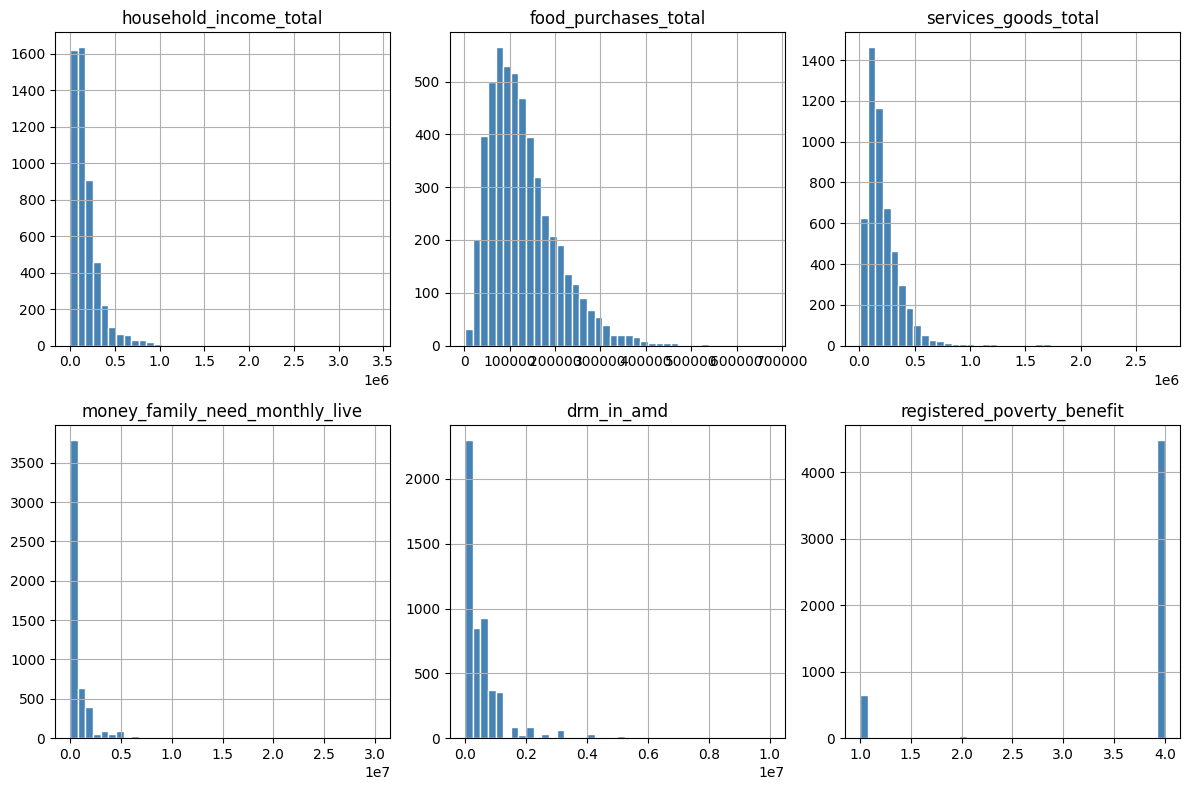

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
for i, col in enumerate(income_cols):
    if col in df.columns and df[col].dtype in [np.float64, np.int64]:
        ax = axes[i]
        df[col].dropna().hist(ax=ax, bins=40, color="steelblue", edgecolor="white")
        ax.set_title(col)
for j in range(len(income_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Assets and housing (selected)

In [7]:
asset_cols = ["household_size", "number_of_rooms", "household_has_car", "has_computer", "dwelling_ownership", "dwelling_condition_estimate"]
asset_cols = [c for c in asset_cols if c in df.columns]
df[asset_cols].describe().T[["count", "mean", "std", "min", "50%", "max"]].round(2)

,count,mean,std,min,50%,max
household_size,5184.0,3.70,1.88,1.0,4.0,19.0
number_of_rooms,5184.0,3.06,1.20,1.0,3.0,10.0
household_has_car,5184.0,1.69,0.46,1.0,2.0,2.0
has_computer,5184.0,1.41,0.49,1.0,1.0,2.0
dwelling_ownership,5184.0,1.22,0.76,1.0,1.0,5.0
dwelling_condition_estimate,5184.0,3.07,0.70,1.0,3.0,5.0


## 6. Correlation (key numeric, excluding IDs and derived)

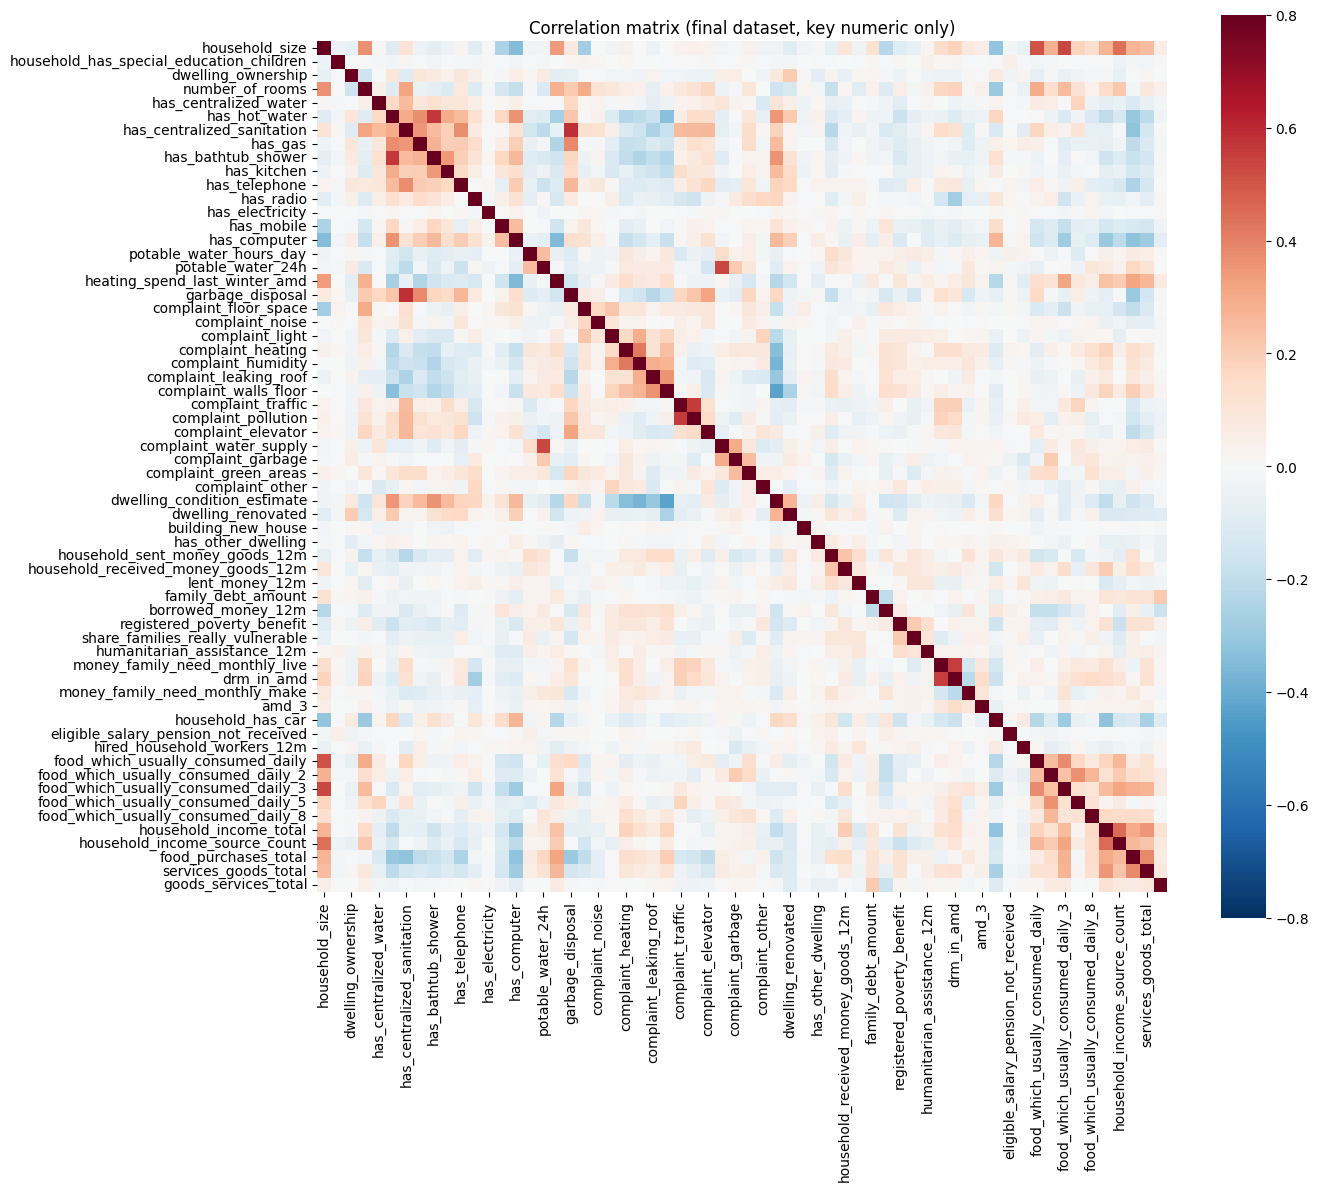

In [8]:
exclude = {"recno", "date", "year", "weight", "sample_weight", "tsne_1", "tsne_2", "cluster"}
num_for_corr = [c for c in numeric.columns if c not in exclude]
corr = df[num_for_corr].corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-0.8, vmax=0.8, ax=ax, square=True)
ax.set_title("Correlation matrix (final dataset, key numeric only)")
plt.tight_layout()
plt.show()

## 7. Cluster vs income and area

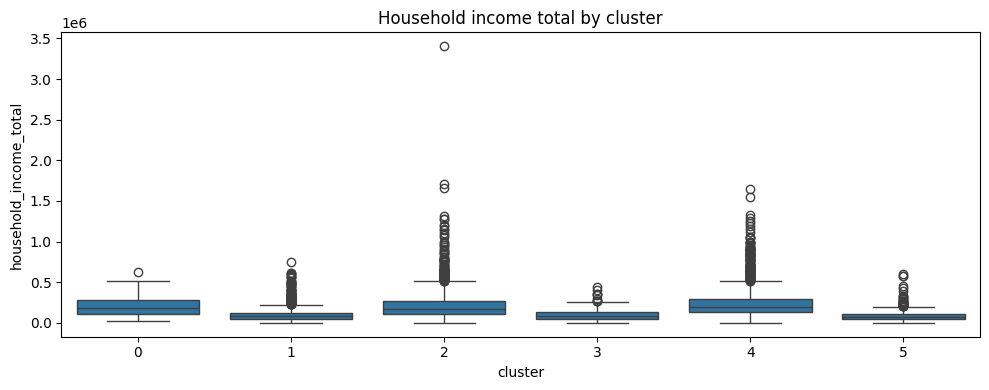

Cluster × area_type_label (counts):
area_type_label  Yerevan  area_0  other urban
cluster                                      
0                      4       4           91
1                    691     524           64
2                    246      26          922
3                      3       0          146
4                    784     790           63
5                    108      60          658


In [9]:
if "cluster" in df.columns and "household_income_total" in df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(data=df, x="cluster", y="household_income_total", ax=ax)
    ax.set_title("Household income total by cluster")
    plt.tight_layout()
    plt.show()
if "cluster" in df.columns and "area_type_label" in df.columns:
    print("Cluster × area_type_label (counts):")
    print(pd.crosstab(df["cluster"], df["area_type_label"]))